In [1]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv('Housing_cleaned.csv')
df

,Unnamed: 0,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus
0,0,13300000,7420,4,2,3,1,2,2,2,1,2,1,1
1,1,12250000,8960,4,4,4,1,2,2,2,1,3,2,1
2,2,12250000,9960,3,2,2,1,2,1,2,2,2,1,2
3,3,12215000,7500,4,2,2,1,2,1,2,1,3,1,1
4,4,11410000,7420,4,1,2,1,1,1,2,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,540,1820000,3000,2,1,1,1,2,1,2,2,2,2,3
541,541,1767150,2400,3,1,1,2,2,2,2,2,0,2,2
542,542,1750000,3620,2,1,1,1,2,2,2,2,0,2,3
543,543,1750000,2910,3,1,1,2,2,2,2,2,0,2,1


In [3]:
df = df.drop('Unnamed: 0', axis=1)
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus
0,13300000,7420,4,2,3,1,2,2,2,1,2,1,1
1,12250000,8960,4,4,4,1,2,2,2,1,3,2,1
2,12250000,9960,3,2,2,1,2,1,2,2,2,1,2
3,12215000,7500,4,2,2,1,2,1,2,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,2,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,2,1,2,2,2,2,3
541,1767150,2400,3,1,1,2,2,2,2,2,0,2,2
542,1750000,3620,2,1,1,1,2,2,2,2,0,2,3
543,1750000,2910,3,1,1,2,2,2,2,2,0,2,1


In [4]:
new_order = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefare', 'furnishingstatus', 'price']

In [5]:
df1 = df[new_order]
df1

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus,price
0,7420,4,2,3,1,2,2,2,1,2,1,1,13300000
1,8960,4,4,4,1,2,2,2,1,3,2,1,12250000
2,9960,3,2,2,1,2,1,2,2,2,1,2,12250000
3,7500,4,2,2,1,2,1,2,1,3,1,1,12215000
4,7420,4,1,2,1,1,1,2,1,2,2,1,11410000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,2,1,2,2,2,2,3,1820000
541,2400,3,1,1,2,2,2,2,2,0,2,2,1767150
542,3620,2,1,1,1,2,2,2,2,0,2,3,1750000
543,2910,3,1,1,2,2,2,2,2,0,2,1,1750000


In [6]:
df1

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefare,furnishingstatus,price
0,7420,4,2,3,1,2,2,2,1,2,1,1,13300000
1,8960,4,4,4,1,2,2,2,1,3,2,1,12250000
2,9960,3,2,2,1,2,1,2,2,2,1,2,12250000
3,7500,4,2,2,1,2,1,2,1,3,1,1,12215000
4,7420,4,1,2,1,1,1,2,1,2,2,1,11410000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,1,2,1,2,2,2,2,3,1820000
541,2400,3,1,1,2,2,2,2,2,0,2,2,1767150
542,3620,2,1,1,1,2,2,2,2,0,2,3,1750000
543,2910,3,1,1,2,2,2,2,2,0,2,1,1750000


In [7]:
X = df1.drop(columns =['price'])
y = df1['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Model Coefficients: {model.coef_[0]:.2f}')
print(f'Model Intercept: {model.intercept_:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Model Coefficients: 235.85
Model Intercept: 6696408.76
Mean Squared Error (MSE): 1771751116594.03
R-squared (R²): 0.65


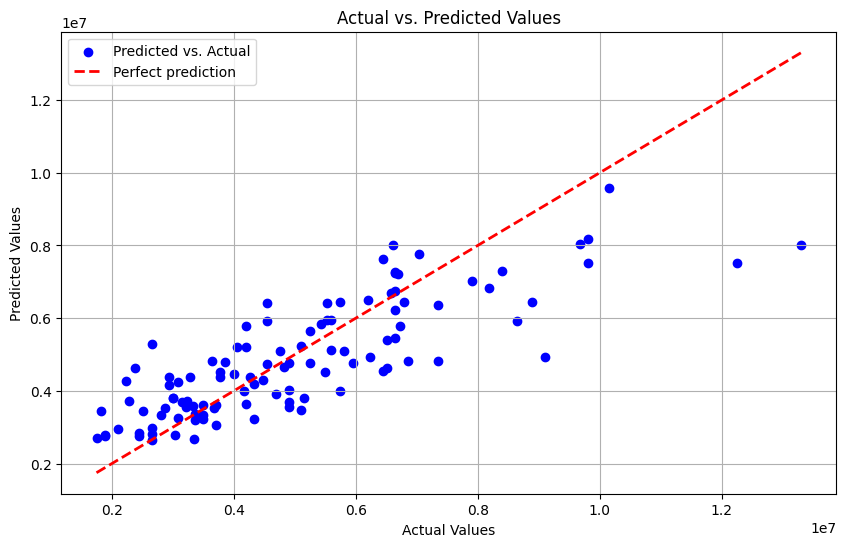

In [10]:
# Plot actual vs. predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs. Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.title('Actual vs. Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
### Create a Pickle file using serialization 
import pickle
pickle_out = open("Housing_price_predictor.pkl","wb")
pickle.dump(model, pickle_out)
pickle_out.close()